# GP-KANの学習安定化方法調査: 変分ベイズ学習

## 0.背景/目的
本notebookでは、GP-KANの変分ベイズ推定による学習結果を評価する：

### モデル構成
- **ネットワーク構造**: 2層GP-KAN (入力1次元 → 中間層1次元 → 出力1次元)
- **誘導点数**: 各GPあたり10点
- **GP構成**: (0,0), (1,0) の2つのガウス過程

### 学習パラメータ
- **エポック数**: 200エポック
- **学習率**: 1e-5
- **バッチサイズ**: 32
- **事前学習**: 無効 (pretrain=False)

## 1.問題設定

真の関数: フーリエ級数
$$f(t) = \frac{4}{\pi} \sum_{n=1}^{N} \frac{1}{n} \sin(nt), \quad n = 1, 3, 5, \ldots, \quad t \in [0, 1]$$
※$N=15$

データ: 
- 合計1,000件: 学習700件/検証150件/評価150件
- tは$(-1,1)$から一様ランダムサンプリング

モデル:
- **1層のGPKAN**: 入力1次元/出力1次元



## 2.メイン処理
本ノートブックのメイン処理を実行する。実行順は以下の通り：

2-1.データセット作成

2-2.GPKANの学習

2-3.精度評価

2-4.学習中のカーネル行列ランク可視化

### 2-1.データセット作成

In [ ]:
# 初期設定: 必要なライブラリをインポートし、パスを設定
import os
import sys

sys.path.append("../../")
import japanize_matplotlib
import torch.utils.data
from lib import model as gplib
from lib import runner
from torch.utils.data import DataLoader

In [ ]:
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset


# Generate synthetic data with Fourier series function
def set_seed(seed=42):
    """完全な再現性のための乱数シード設定"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def worker_init_fn(worker_id):
    """DataLoaderワーカープロセス用の乱数シード設定"""
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


set_seed(42)  # 全体の乱数シード設定
num_samples = 1000

# Generate random input points t from [-1, 1]
t = np.random.uniform(-1, 1, num_samples)


# Compute target values: f(t) = (4/π) * Σ(1/n * sin(nt)) for odd n up to N=15
def fourier_series(t, N=15):
    result = np.zeros_like(t)
    for n in range(1, N + 1, 2):  # odd numbers only: 1, 3, 5, 7, 9, 11, 13, 15
        result += (1 / n) * np.sin(n * t)
    return (4 / np.pi) * result


targets = fourier_series(t, N=15)

# Reshape inputs (t is 1D, but we need it as 2D for compatibility)
inputs = t.reshape(-1, 1)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(inputs)
y_tensor = torch.FloatTensor(targets).reshape(-1, 1)

# Split data into train, validation, and test sets
train_size = int(0.7 * num_samples)
val_size = int(0.15 * num_samples)
test_size = num_samples - train_size - val_size

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]

X_val = X_tensor[train_size : train_size + val_size]
y_val = y_tensor[train_size : train_size + val_size]

X_test = X_tensor[train_size + val_size :]
y_test = y_tensor[train_size + val_size :]

# データを昇順にソート（X_testとy_testを対応を保ちながら）
sorted_indices = torch.argsort(X_test.squeeze())
X_test = X_test[sorted_indices]
y_test = y_test[sorted_indices]

# Create datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Create dataloaders
batch_size = 32

In [ ]:
# Create dataloaders with reproducible worker processes
generator = torch.Generator()
generator.manual_seed(42)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)
test_dataloader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Single process for reproducibility
    worker_init_fn=worker_init_fn,
    generator=generator,
)

Train samples: 700
Validation samples: 150
Test samples: 150


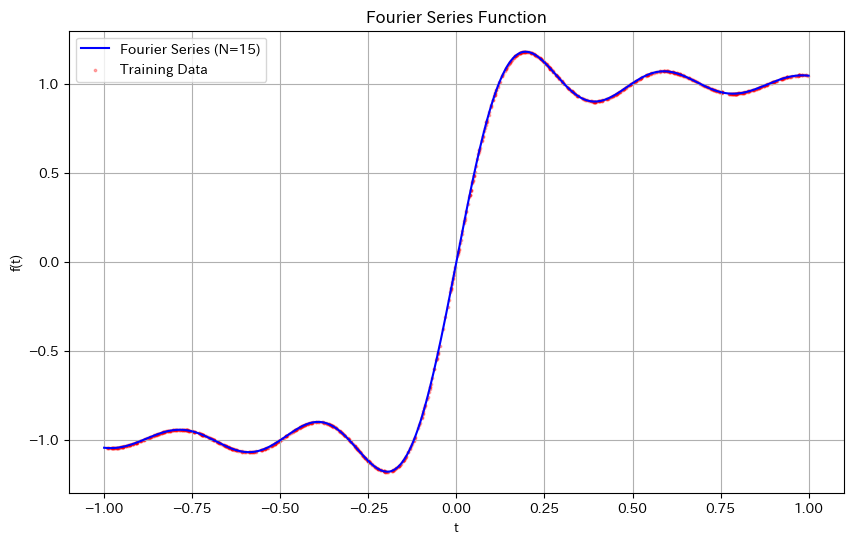

In [ ]:
# サンプル数確認
print(f"Train samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

# Fourier級数関数のプロット
t_plot = np.linspace(-1, 1, 1000)
y_plot = fourier_series(t_plot, N=15)
plt.figure(figsize=(10, 6))
plt.plot(t_plot, y_plot, "b-", label="Fourier Series (N=15)")
plt.scatter(t, targets, alpha=0.3, s=3, c="red", label="Training Data")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.title("Fourier Series Function")
plt.legend()
plt.grid(True)
plt.show()

### 2-2.モデル学習

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import MultivariateNormal, kl_divergence


class StableVariationalGPKANLayer(nn.Module):
    def __init__(self, input_dim, output_dim, num_inducing, input_bounds=(-2, 2)):
        super().__init__()

        self.input_dim = input_dim
        self.output_dim = output_dim
        self.num_inducing = num_inducing
        self.input_bounds = input_bounds

        # 改良1: 誘導点の適切な初期化 (等間隔配置)
        self.inducing_points = nn.Parameter(
            self._initialize_inducing_points(num_inducing, input_dim, input_bounds)
        )

        # 改良2: 変分分布パラメータの安定化（Cholesky分解を使わない）
        self.variational_mean = nn.Parameter(torch.zeros(num_inducing, output_dim))

        # 変分分散を直接パラメータ化（正定値制約付き）
        self.log_variational_variance = nn.Parameter(
            torch.zeros(num_inducing, output_dim)
        )

        # 改良3: ハイパーパラメータの適切な初期化
        input_range = input_bounds[1] - input_bounds[0]
        initial_lengthscale = input_range / (2 * np.sqrt(num_inducing))
        self.log_lengthscale = nn.Parameter(
            torch.log(torch.full((input_dim,), initial_lengthscale))
        )
        self.log_variance = nn.Parameter(torch.log(torch.tensor(1.0)))
        self.log_noise = nn.Parameter(torch.log(torch.tensor(0.1)))

        # 改良4: 適応的Jitter
        self.min_jitter = 1e-4
        self.adaptive_jitter_scale = 1e-2

    def _initialize_inducing_points(self, num_inducing, input_dim, bounds):
        """誘導点の等間隔初期化"""
        if input_dim == 1:
            # 1次元の場合は等間隔配置
            points = torch.linspace(bounds[0], bounds[1], num_inducing).unsqueeze(1)
        else:
            # 多次元の場合はグリッド配置
            points_per_dim = int(np.ceil(num_inducing ** (1 / input_dim)))
            coords = []
            for _ in range(input_dim):
                coords.append(torch.linspace(bounds[0], bounds[1], points_per_dim))

            grid = torch.meshgrid(coords, indexing="ij")
            points = torch.stack([g.flatten() for g in grid], dim=1)[:num_inducing]

            # 不足分は既存点に小さなノイズを加えて補完
            if points.shape[0] < num_inducing:
                extra_points = points[: num_inducing - points.shape[0]].clone()
                extra_points += 0.01 * torch.randn_like(extra_points)
                points = torch.cat([points, extra_points], dim=0)

        return points

    @property
    def lengthscale(self):
        """制約付き長さスケール"""
        return torch.clamp(torch.exp(self.log_lengthscale), min=1e-2, max=10.0)

    @property
    def variance(self):
        """制約付き分散"""
        return torch.clamp(torch.exp(self.log_variance), min=1e-2, max=100.0)

    @property
    def noise(self):
        """制約付きノイズ分散"""
        return torch.clamp(torch.exp(self.log_noise), min=1e-4, max=1.0)

    @property
    def variational_variance(self):
        """制約付き変分分散"""
        return torch.clamp(torch.exp(self.log_variational_variance), min=1e-4, max=10.0)

    def kernel(self, x1, x2):
        """安定化されたRBFカーネル"""
        # スケーリング
        scaled_x1 = x1 / self.lengthscale
        scaled_x2 = x2 / self.lengthscale

        # 距離計算
        sq_dists = torch.cdist(scaled_x1, scaled_x2, p=2) ** 2

        # カーネル値の計算（数値安定化）
        kernel_vals = self.variance * torch.exp(-0.5 * torch.clamp(sq_dists, max=50.0))

        return kernel_vals

    def _get_adaptive_jitter(self, K):
        """適応的Jitter計算"""
        # カーネル行列の条件数に基づいてJitterを調整
        try:
            eigenvals = torch.linalg.eigvals(K).real
            min_eigenval = torch.min(eigenvals)
            max_eigenval = torch.max(eigenvals)

            if min_eigenval <= 0:
                # 負の固有値がある場合は大きなJitterを追加
                adaptive_jitter = max(self.adaptive_jitter_scale, -2 * min_eigenval)
            else:
                # 条件数に基づく調整
                cond_num = max_eigenval / min_eigenval
                if cond_num > 1e12:
                    adaptive_jitter = self.adaptive_jitter_scale * (cond_num / 1e12)
                else:
                    adaptive_jitter = self.min_jitter

        except Exception:
            # 固有値計算が失敗した場合のフォールバック
            adaptive_jitter = self.adaptive_jitter_scale

        return max(adaptive_jitter, self.min_jitter)

    def forward(self, x, return_var=True):
        """安定化された順伝播（Cholesky分解なし）"""
        N = x.shape[0]
        M = self.inducing_points.shape[0]

        try:
            # カーネル行列の計算
            K_uu = self.kernel(self.inducing_points, self.inducing_points)
            K_uf = self.kernel(self.inducing_points, x)
            K_ff_diag = self.variance.expand(N)

            # 適応的Jitter
            adaptive_jitter = self._get_adaptive_jitter(K_uu)
            jitter_matrix = adaptive_jitter * torch.eye(M, device=K_uu.device)

            # 安定化されたCholesky分解
            K_uu_stable = K_uu + jitter_matrix

            # Cholesky分解の試行
            try:
                L_uu = torch.linalg.cholesky(K_uu_stable)
            except Exception:
                # Cholesky分解が失敗した場合の対処
                print(
                    f"Warning: Cholesky decomposition failed, using eigendecomposition"
                )
                eigenvals, eigenvecs = torch.linalg.eigh(K_uu_stable)
                eigenvals = torch.clamp(eigenvals, min=self.min_jitter)
                K_uu_stable = eigenvecs @ torch.diag(eigenvals) @ eigenvecs.T
                L_uu = torch.linalg.cholesky(K_uu_stable)

            # 予測平均の計算
            alpha = torch.linalg.solve_triangular(L_uu, K_uf, upper=False)
            pred_mean = torch.einsum("mn,mo->no", alpha, self.variational_mean)

            if not return_var:
                return pred_mean

            # 予測分散の計算（対角変分分散を使用）
            var_term1 = K_ff_diag.unsqueeze(-1).expand(-1, self.output_dim)
            var_term2 = (
                -torch.sum(alpha**2, dim=0).unsqueeze(-1).expand(-1, self.output_dim)
            )

            # 変分項の計算（対角分散を使用）
            var_term3 = torch.zeros(N, self.output_dim, device=x.device)
            variational_var = self.variational_variance  # Shape: [M, output_dim]

            for d in range(self.output_dim):
                # 対角分散行列を使用した簡単な計算
                var_term3[:, d] = torch.sum(
                    alpha**2 * variational_var[:, d].unsqueeze(1), dim=0
                )

            pred_var = var_term1 + var_term2 + var_term3 + self.noise
            pred_var = torch.clamp(pred_var, min=1e-4, max=100.0)

            return pred_mean, pred_var

        except Exception as e:
            print(f"Error in forward pass: {e}")
            # エラー時のフォールバック
            pred_mean = torch.zeros(N, self.output_dim, device=x.device)
            pred_var = torch.ones(N, self.output_dim, device=x.device) * 0.1
            return pred_mean, pred_var

In [ ]:
class StableVariationalGPKAN(nn.Module):
    def __init__(self, layer_dims, num_inducing_per_layer, input_bounds=(-2, 2)):
        super().__init__()

        self.layers = nn.ModuleList()
        self.layer_dims = layer_dims

        for i in range(len(layer_dims) - 1):
            input_dim = layer_dims[i]
            output_dim = layer_dims[i + 1]

            # 最初の層は入力範囲を指定、以降は適応的に設定
            if i == 0:
                bounds = input_bounds
            else:
                bounds = (-3, 3)  # 中間層の適当な範囲

            layer = StableVariationalGPKANLayer(
                input_dim, output_dim, num_inducing_per_layer, bounds
            )
            self.layers.append(layer)

    def forward(self, x, num_samples=1):
        current_mean = x
        current_var = torch.zeros_like(x[:, :1])

        for layer_idx, layer in enumerate(self.layers):
            try:
                if num_samples == 1:
                    current_mean, current_var = layer(current_mean, return_var=True)
                else:
                    sample_means = []
                    sample_vars = []

                    for _ in range(num_samples):
                        if current_var.sum() > 0:
                            noise = torch.randn_like(current_mean) * torch.sqrt(
                                torch.clamp(current_var, min=1e-8)
                            )
                            sample_input = current_mean + noise
                        else:
                            sample_input = current_mean

                        sample_mean, sample_var = layer(sample_input, return_var=True)
                        sample_means.append(sample_mean)
                        sample_vars.append(sample_var)

                    sample_means = torch.stack(sample_means)
                    sample_vars = torch.stack(sample_vars)

                    current_mean = torch.mean(sample_means, dim=0)
                    current_var = torch.mean(sample_vars, dim=0) + torch.var(
                        sample_means, dim=0
                    )

            except Exception as e:
                print(f"Error in layer {layer_idx}: {e}")
                # エラー時は前の値を保持
                pass

        return current_mean, current_var

    def elbo(self, x, y, num_samples=3):
        """改良されたELBO計算"""
        try:
            # KL項の計算
            kl_total = 0
            for layer_idx, layer in enumerate(self.layers):
                try:
                    m = layer.variational_mean
                    S_diag = layer.variational_variance  # Shape: [M, output_dim]

                    K_uu = layer.kernel(layer.inducing_points, layer.inducing_points)
                    adaptive_jitter = layer._get_adaptive_jitter(K_uu)
                    jitter_matrix = adaptive_jitter * torch.eye(
                        K_uu.shape[0], device=K_uu.device
                    )
                    K_uu_stable = K_uu + jitter_matrix

                    for d in range(layer.output_dim):
                        S_d = torch.diag(S_diag[:, d])

                        # 数値安定性のチェック
                        if torch.any(torch.isnan(S_d)) or torch.any(torch.isinf(S_d)):
                            continue

                        try:
                            q_u = MultivariateNormal(
                                m[:, d],
                                S_d + 1e-5 * torch.eye(S_d.shape[0], device=S_d.device),
                            )
                            p_u = MultivariateNormal(
                                torch.zeros_like(m[:, d]), K_uu_stable
                            )

                            kl_term = kl_divergence(q_u, p_u)
                            if not torch.isnan(kl_term) and not torch.isinf(kl_term):
                                kl_total += kl_term

                        except Exception:
                            # KL計算が失敗した場合はスキップ
                            continue

                except Exception as e:
                    print(f"Error in KL computation for layer {layer_idx}: {e}")
                    continue

            # 期待対数尤度項の計算
            log_likelihood = 0
            for _ in range(num_samples):
                try:
                    pred_mean, pred_var = self.forward(x, num_samples=1)

                    # 数値安定性チェック
                    if torch.any(torch.isnan(pred_mean)) or torch.any(
                        torch.isnan(pred_var)
                    ):
                        continue

                    # 観測モデル
                    pred_var_clamped = torch.clamp(pred_var.squeeze(), min=1e-4)
                    pred_dist = MultivariateNormal(
                        pred_mean.squeeze(), torch.diag_embed(pred_var_clamped)
                    )

                    ll = pred_dist.log_prob(y.squeeze())
                    if not torch.isnan(ll) and not torch.isinf(ll):
                        log_likelihood += ll / num_samples

                except Exception:
                    continue

            # ELBO計算
            elbo = log_likelihood.sum() - kl_total

            # 数値安定性チェック
            if torch.isnan(elbo) or torch.isinf(elbo):
                return torch.tensor(1e6, device=x.device)  # 大きなペナルティ

            return -elbo

        except Exception as e:
            print(f"Error in ELBO computation: {e}")
            return torch.tensor(1e6, device=x.device)

In [ ]:
import time


def train_stable_variational_gpkan(
    model, train_loader, val_loader, epochs=500, lr=1e-3
):
    """安定化された学習関数"""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.8, patience=20, verbose=True
    )

    model.train()
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    patience_counter = 0
    max_patience = 50

    for epoch in range(epochs):
        # 学習フェーズ
        model.train()
        epoch_train_loss = 0
        valid_batches = 0

        for batch_idx, (x_batch, y_batch) in enumerate(train_loader):
            try:
                optimizer.zero_grad()

                # ELBO loss の計算
                loss = model.elbo(x_batch, y_batch, num_samples=2)

                # 異常値チェック
                if torch.isnan(loss) or torch.isinf(loss) or loss > 1e6:
                    print(f"Skipping batch {batch_idx} due to numerical instability")
                    continue

                loss.backward()

                # 勾配クリッピング
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)

                # パラメータの異常値チェック
                param_norms = []
                for param in model.parameters():
                    if param.grad is not None:
                        param_norms.append(param.grad.norm())

                if any(torch.isnan(norm) or torch.isinf(norm) for norm in param_norms):
                    print(f"Skipping optimizer step due to gradient issues")
                    continue

                optimizer.step()
                epoch_train_loss += loss.item()
                valid_batches += 1

            except Exception as e:
                print(f"Error in training batch {batch_idx}: {e}")
                continue

        if valid_batches == 0:
            print(f"No valid batches in epoch {epoch}")
            break

        # 検証フェーズ
        model.eval()
        with torch.no_grad():
            epoch_val_loss = 0
            valid_val_batches = 0

            for x_batch, y_batch in val_loader:
                try:
                    val_loss = model.elbo(x_batch, y_batch, num_samples=1)

                    if not (
                        torch.isnan(val_loss) or torch.isinf(val_loss) or val_loss > 1e6
                    ):
                        epoch_val_loss += val_loss.item()
                        valid_val_batches += 1

                except Exception:
                    continue

            if valid_val_batches == 0:
                print(f"No valid validation batches in epoch {epoch}")
                continue

        avg_train_loss = epoch_train_loss / valid_batches
        avg_val_loss = epoch_val_loss / valid_val_batches

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # 学習率スケジューリング
        scheduler.step(avg_val_loss)

        # 早期停止
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= max_patience:
            print(f"Early stopping at epoch {epoch}")
            break

        if epoch % 25 == 0:
            print(
                f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}"
            )

            # パラメータ状態の診断
            for layer_idx, layer in enumerate(model.layers):
                try:
                    K_uu = layer.kernel(layer.inducing_points, layer.inducing_points)
                    eigenvals = torch.linalg.eigvals(K_uu).real
                    min_eigenval = torch.min(eigenvals).item()
                    print(f"  Layer {layer_idx}: min eigenval = {min_eigenval:.2e}")
                except Exception:
                    print(f"  Layer {layer_idx}: eigenvalue computation failed")

    return train_losses, val_losses


# 使用例
layer_dims = [1, 1]
num_inducing = 10  # 少し減らして安定性を向上

model = StableVariationalGPKAN(layer_dims, num_inducing, input_bounds=(-1, 1))

# 学習時間を計測
start_time = time.time()
train_losses, val_losses = train_stable_variational_gpkan(
    model, train_dataloader, val_dataloader, epochs=300, lr=5e-4
)
end_time = time.time()

print(f"\n学習時間: {end_time - start_time:.2f} 秒")

/Users/daisuke_takehara/Desktop/workdir_gpkan/.venv/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 0: Train Loss = 347.5172, Val Loss = 297.3515
  Layer 0: min eigenval = 2.36e-03
Epoch 25: Train Loss = 30.1709, Val Loss = 28.6377
  Layer 0: min eigenval = 1.65e-01
Epoch 50: Train Loss = 18.0773, Val Loss = 17.6557
  Layer 0: min eigenval = 1.53e-01
Epoch 75: Train Loss = 12.5950, Val Loss = 12.6826
  Layer 0: min eigenval = 1.16e-01
Epoch 100: Train Loss = 9.1669, Val Loss = 9.5738
  Layer 0: min eigenval = 9.48e-02
Epoch 125: Train Loss = 6.5253, Val Loss = 7.1792
  Layer 0: min eigenval = 7.97e-02
Epoch 150: Train Loss = 4.3519, Val Loss = 5.2224
  Layer 0: min eigenval = 6.77e-02
Epoch 175: Train Loss = 2.4432, Val Loss = 3.5000
  Layer 0: min eigenval = 5.85e-02
Epoch 200: Train Loss = 0.8029, Val Loss = 2.0078
  Layer 0: min eigenval = 5.05e-02
Epoch 225: Train Loss = -0.9021, Val Loss = 0.4564
  Layer 0: min eigenval = 4.50e-02
Epoch 250: Train Loss = -2.6388, Val Loss = -1.1506
  Layer 0: min eigenval = 4.01e-02
Epoch 275: Train Loss = -4.3283, Val Loss = -2.7775
  Lay

In [ ]:
np.random.seed(42)  # for reproducibility
torch.manual_seed(42)  # for reproducibility

## 3.結果評価
以下の項目に従ってカーネル行列の分析結果をまとめる：

**カーネル行列分析項目**
- 各層のカーネル行列ランクと条件数の分析
- 誘導点の分布と配置の可視化
- カーネル行列のヒートマップ（Jitter項適用前後）
- 固有値分布の分析
- 誘導点間距離の統計的分析

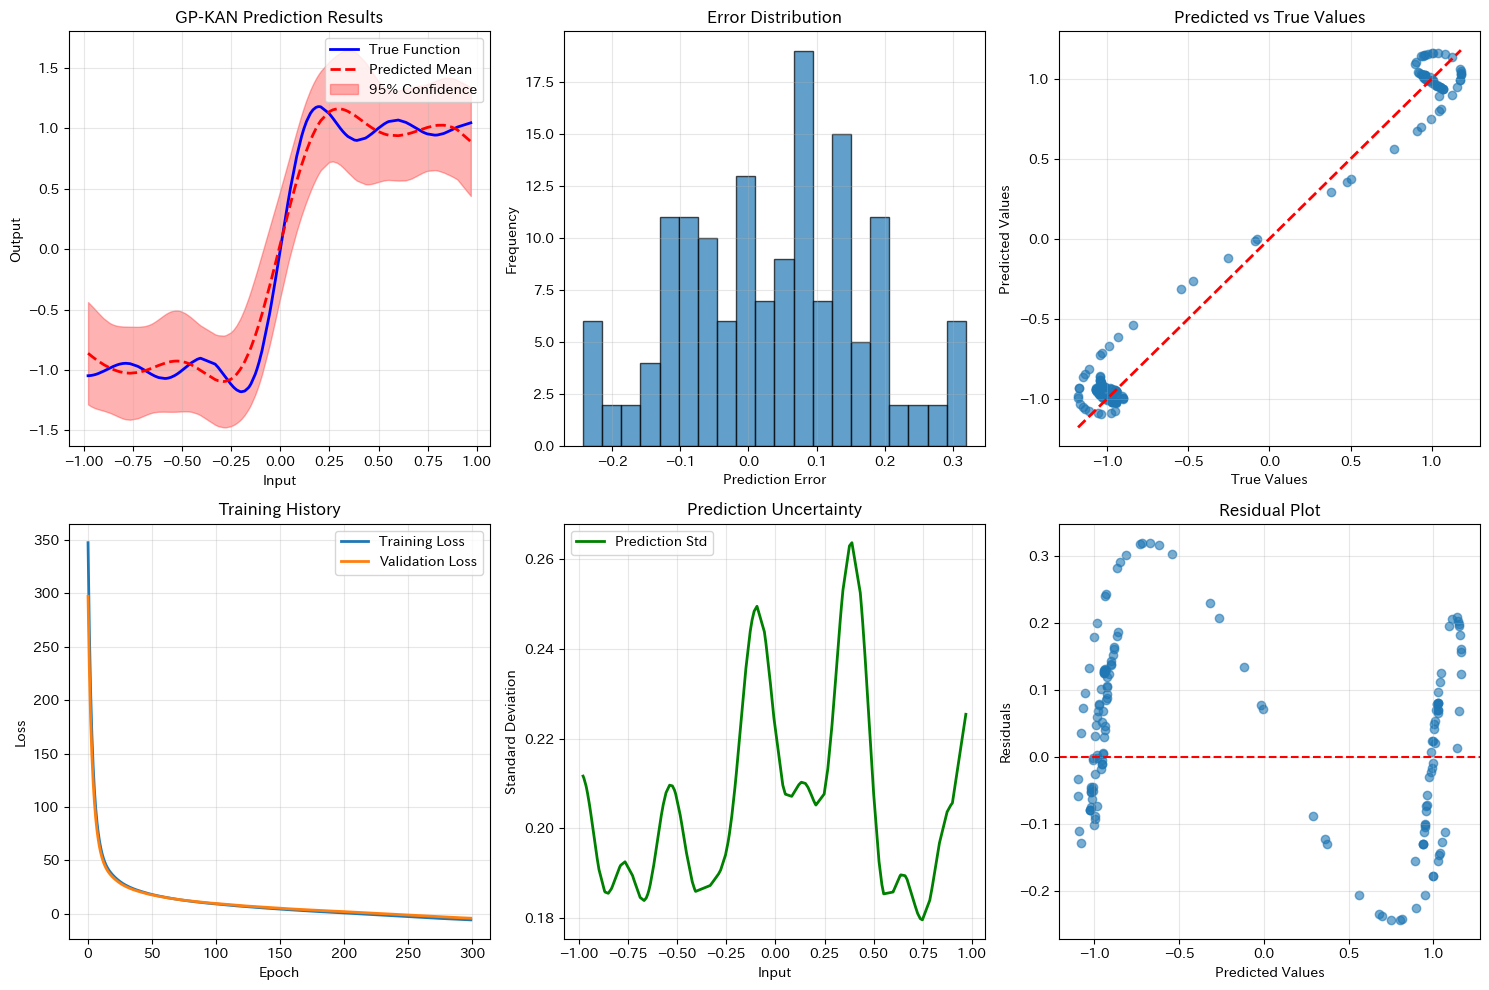

=== 予測性能評価 ===
Mean Squared Error (MSE): 0.018957
Root Mean Squared Error (RMSE): 0.137685
Mean Absolute Error (MAE): 0.113677
R² Score: 0.980592
Test Data Range: [-1.1802, 1.1802]
Prediction Range: [-1.0951, 1.1618]

=== 学習後のモデルパラメータ ===

Layer 0:
  Lengthscale: [0.20681629]
  Variance: 0.47870704531669617
  Noise: 0.003767482005059719
  Inducing points range: [-1.0740, 0.9377]
  Variational mean range: [-1.1319, 1.2276]


In [ ]:
# モデルの予測性能評価
import matplotlib.pyplot as plt
import numpy as np
import torch

# テストデータでの予測
model.eval()
with torch.no_grad():
    pred_mean, pred_var = model(X_test)

# 予測結果の可視化
plt.figure(figsize=(15, 10))

# 1. 予測結果のプロット
plt.subplot(2, 3, 1)
x_test_np = X_test.squeeze().numpy()
y_test_np = y_test.squeeze().numpy()
pred_mean_np = pred_mean.squeeze().detach().numpy()
pred_std_np = torch.sqrt(torch.clamp(pred_var, min=1e-4)).squeeze().detach().numpy()

plt.plot(x_test_np, y_test_np, "b-", label="True Function", linewidth=2)
plt.plot(x_test_np, pred_mean_np, "r--", label="Predicted Mean", linewidth=2)
plt.fill_between(
    x_test_np,
    pred_mean_np - 2 * pred_std_np,
    pred_mean_np + 2 * pred_std_np,
    alpha=0.3,
    color="red",
    label="95% Confidence",
)
plt.xlabel("Input")
plt.ylabel("Output")
plt.title("GP-KAN Prediction Results")
plt.legend()
plt.grid(True, alpha=0.3)

# 2. 予測誤差の分布
plt.subplot(2, 3, 2)
errors = pred_mean_np - y_test_np
plt.hist(errors, bins=20, alpha=0.7, edgecolor="black")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Error Distribution")
plt.grid(True, alpha=0.3)

# 3. 予測 vs 実測値の散布図
plt.subplot(2, 3, 3)
plt.scatter(y_test_np, pred_mean_np, alpha=0.6)
plt.plot(
    [y_test_np.min(), y_test_np.max()],
    [y_test_np.min(), y_test_np.max()],
    "r--",
    linewidth=2,
)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs True Values")
plt.grid(True, alpha=0.3)

# 4. 学習曲線
plt.subplot(2, 3, 4)
plt.plot(train_losses, label="Training Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()
plt.grid(True, alpha=0.3)

# 5. 予測の不確実性
plt.subplot(2, 3, 5)
plt.plot(x_test_np, pred_std_np, "g-", linewidth=2, label="Prediction Std")
plt.xlabel("Input")
plt.ylabel("Standard Deviation")
plt.title("Prediction Uncertainty")
plt.legend()
plt.grid(True, alpha=0.3)

# 6. 残差プロット
plt.subplot(2, 3, 6)
plt.scatter(pred_mean_np, errors, alpha=0.6)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 数値的評価指標の計算
mse = np.mean(errors**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(errors))
r2 = 1 - np.sum(errors**2) / np.sum((y_test_np - np.mean(y_test_np)) ** 2)

print("=== 予測性能評価 ===")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"R² Score: {r2:.6f}")
print(f"Test Data Range: [{y_test_np.min():.4f}, {y_test_np.max():.4f}]")
print(f"Prediction Range: [{pred_mean_np.min():.4f}, {pred_mean_np.max():.4f}]")

# 各層のパラメータ状態の確認
print("\n=== 学習後のモデルパラメータ ===")
for layer_idx, layer in enumerate(model.layers):
    print(f"\nLayer {layer_idx}:")
    print(f"  Lengthscale: {layer.lengthscale.detach().numpy()}")
    print(f"  Variance: {layer.variance.detach().numpy()}")
    print(f"  Noise: {layer.noise.detach().numpy()}")

    # 誘導点の範囲
    z_points = layer.inducing_points.detach()
    print(
        f"  Inducing points range: [{z_points.min().item():.4f}, {z_points.max().item():.4f}]"
    )

    # 変分パラメータの統計
    var_mean = layer.variational_mean.detach()
    print(
        f"  Variational mean range: [{var_mean.min().item():.4f}, {var_mean.max().item():.4f}]"
    )

元のテスト範囲: [-0.978, 0.969]
第1層誘導点範囲: [-1.074, 0.938]
拡張テスト範囲: [-1.574, 1.469]


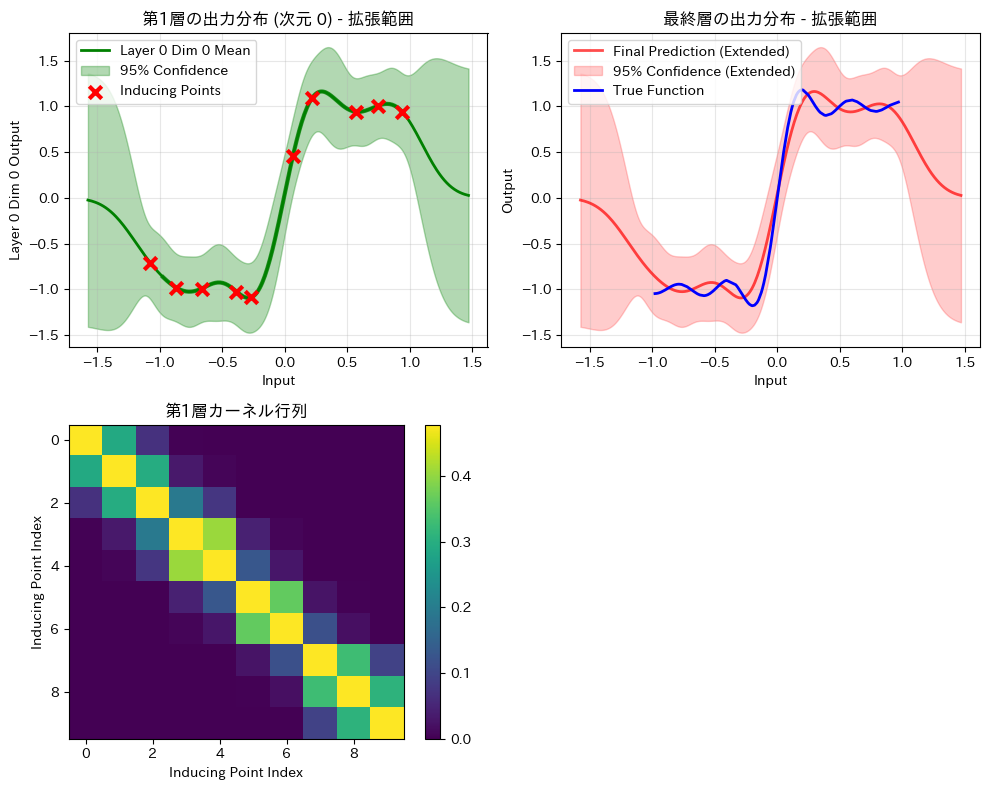

In [ ]:
# 各層の予測分布を可視化
import matplotlib.pyplot as plt
import numpy as np
import torch

# 誘導点の範囲を考慮した拡張テストデータを作成
layer0_z_range = model.layers[0].inducing_points.detach()
# layer1_z_range = model.layers[1].inducing_points.detach()

# 各層の誘導点の範囲を取得
layer0_min, layer0_max = layer0_z_range.min().item(), layer0_z_range.max().item()
# layer1_min, layer1_max = layer1_z_range.min().item(), layer1_z_range.max().item()

# 元のテストデータの範囲
orig_min, orig_max = X_test.min().item(), X_test.max().item()

# 拡張範囲を決定（誘導点を含む範囲）
extended_min = min(orig_min, layer0_min) - 0.5
# extended_min = min(orig_min, layer0_min, layer1_min) - 0.5
extended_max = max(orig_max, layer0_max) + 0.5
# extended_max = max(orig_max, layer0_max, layer1_max) + 0.5

print(f"元のテスト範囲: [{orig_min:.3f}, {orig_max:.3f}]")
print(f"第1層誘導点範囲: [{layer0_min:.3f}, {layer0_max:.3f}]")
# print(f"第2層誘導点範囲: [{layer1_min:.3f}, {layer1_max:.3f}]")
print(f"拡張テスト範囲: [{extended_min:.3f}, {extended_max:.3f}]")

# 拡張テストデータを作成
n_extended = 300
X_extended = torch.linspace(extended_min, extended_max, n_extended).unsqueeze(1)

# モデルの各層の出力を取得
model.eval()
with torch.no_grad():
    # 第1層の出力
    layer_0_mean_ext, layer_0_var_ext = model.layers[0](X_extended)

    # # 第2層の出力（中間層）
    # layer_1_mean_ext, layer_1_var_ext = model.layers[1](layer_0_mean_ext)

    # 最終層の出力
    final_mean_ext, final_var_ext = model(X_extended)

# データの準備とソート
x_extended_np = X_extended.squeeze().numpy()
layer_0_mean_ext_np = layer_0_mean_ext.detach().numpy()
layer_0_std_ext_np = torch.sqrt(torch.clamp(layer_0_var_ext, min=1e-5)).detach().numpy()
# layer_1_mean_ext_np = layer_1_mean_ext.detach().numpy()
# layer_1_std_ext_np = torch.sqrt(torch.clamp(layer_1_var_ext, min=1e-5)).detach().numpy()
final_mean_ext_np = final_mean_ext.squeeze().detach().numpy()
final_std_ext_np = (
    torch.sqrt(torch.clamp(final_var_ext, min=1e-5)).squeeze().detach().numpy()
)

# 可視化のための次元数を決定
num_dims_layer0 = layer_0_mean_ext.shape[1]
# num_dims_layer1 = layer_1_mean_ext.shape[1]
max_dims_to_show = 4

# 実際に表示する次元数を計算
dims_layer0_to_show = min(num_dims_layer0, max_dims_to_show)
# dims_layer1_to_show = min(num_dims_layer1, max_dims_to_show)

# プロット数を計算（第1層 + 第2層 + 最終層 + 2つのカーネル行列）
total_plots = dims_layer0_to_show + 3  # 最終層と2つのカーネル行列
# total_plots = dims_layer0_to_show + dims_layer1_to_show + 3  # 最終層と2つのカーネル行列

# グリッドサイズを決定
if total_plots <= 4:
    rows, cols = 2, 2
elif total_plots <= 6:
    rows, cols = 2, 3
elif total_plots <= 9:
    rows, cols = 3, 3
else:
    rows, cols = 3, 4

plt.figure(figsize=(5 * cols, 4 * rows))

plot_idx = 1

# 第1層の各次元の出力分布（誘導点付き）
for dim in range(dims_layer0_to_show):
    plt.subplot(rows, cols, plot_idx)
    layer_0_mean_dim = layer_0_mean_ext_np[:, dim]
    layer_0_std_dim = layer_0_std_ext_np[:, dim]

    # 拡張範囲での予測
    plt.plot(
        x_extended_np,
        layer_0_mean_dim,
        "g-",
        label=f"Layer 0 Dim {dim} Mean",
        linewidth=2,
    )
    plt.fill_between(
        x_extended_np,
        layer_0_mean_dim - 2 * layer_0_std_dim,
        layer_0_mean_dim + 2 * layer_0_std_dim,
        alpha=0.3,
        color="green",
        label="95% Confidence",
    )

    # 元のテスト範囲を強調
    orig_mask = (x_extended_np >= orig_min) & (x_extended_np <= orig_max)
    plt.plot(
        x_extended_np[orig_mask],
        layer_0_mean_dim[orig_mask],
        "g-",
        linewidth=3,
        alpha=0.8,
    )

    # 第1層の誘導点を追加
    z_points_layer0 = model.layers[0].inducing_points.detach().numpy()
    if z_points_layer0.shape[1] == 1:
        # 誘導点でのGP出力を計算
        with torch.no_grad():
            z_output, _ = model.layers[0](model.layers[0].inducing_points)
        z_output_dim = z_output[:, dim].detach().numpy()
        plt.scatter(
            z_points_layer0[:, 0],
            z_output_dim,
            color="red",
            s=80,
            marker="x",
            linewidth=3,
            label="Inducing Points",
            zorder=5,
        )

    plt.xlabel("Input")
    plt.ylabel(f"Layer 0 Dim {dim} Output")
    plt.title(f"第1層の出力分布 (次元 {dim}) - 拡張範囲")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plot_idx += 1

# # 第2層の各次元の出力分布（誘導点付き）
# for dim in range(dims_layer1_to_show):
#     plt.subplot(rows, cols, plot_idx)
#     layer_1_mean_dim = layer_1_mean_ext_np[:, dim]
#     layer_1_std_dim = layer_1_std_ext_np[:, dim]

#     # 拡張範囲での予測
#     plt.plot(
#         x_extended_np,
#         layer_1_mean_dim,
#         "b-",
#         label=f"Layer 1 Dim {dim} Mean",
#         linewidth=2,
#     )
#     plt.fill_between(
#         x_extended_np,
#         layer_1_mean_dim - 2 * layer_1_std_dim,
#         layer_1_mean_dim + 2 * layer_1_std_dim,
#         alpha=0.3,
#         color="blue",
#         label="95% Confidence",
#     )

#     # 元のテスト範囲を強調
#     orig_mask = (x_extended_np >= orig_min) & (x_extended_np <= orig_max)
#     plt.plot(
#         x_extended_np[orig_mask],
#         layer_1_mean_dim[orig_mask],
#         "b-",
#         linewidth=3,
#         alpha=0.8,
#     )

#     # 第2層の誘導点を追加（第1層の出力空間での誘導点）
#     z_points_layer1 = model.layers[1].inducing_points.detach().numpy()
#     if z_points_layer1.shape[1] > dim:
#         # 第2層の誘導点での出力を計算
#         with torch.no_grad():
#             z_output_layer1, _ = model.layers[1](model.layers[1].inducing_points)
#         if z_output_layer1.shape[1] > dim:
#             z_output_dim = z_output_layer1[:, dim].detach().numpy()
#             if z_points_layer1.shape[1] == 1:
#                 x_coord = z_points_layer1[:, 0]
#             else:
#                 x_coord = z_points_layer1[:, dim]
#             plt.scatter(
#                 x_coord,
#                 z_output_dim,
#                 color="red",
#                 s=80,
#                 marker="x",
#                 linewidth=3,
#                 label="Inducing Points",
#                 zorder=5,
#             )

#     plt.xlabel("Input")
#     plt.ylabel(f"Layer 1 Dim {dim} Output")
#     plt.title(f"第2層の出力分布 (次元 {dim}) - 拡張範囲")
#     plt.legend()
#     plt.grid(True, alpha=0.3)
#     plot_idx += 1

# 最終層の出力分布（予測結果）
plt.subplot(rows, cols, plot_idx)

# 拡張範囲での最終予測
plt.plot(
    x_extended_np,
    final_mean_ext_np,
    "r-",
    label="Final Prediction (Extended)",
    linewidth=2,
    alpha=0.7,
)
plt.fill_between(
    x_extended_np,
    final_mean_ext_np - 2 * final_std_ext_np,
    final_mean_ext_np + 2 * final_std_ext_np,
    alpha=0.2,
    color="red",
    label="95% Confidence (Extended)",
)


# 元のテストデータでの真の関数
sort_idx = np.argsort(x_test_np)
x_test_sorted = x_test_np[sort_idx]
y_test_sorted = y_test_np[sort_idx]
plt.plot(x_test_sorted, y_test_sorted, "b-", label="True Function", linewidth=2)


plt.xlabel("Input")
plt.ylabel("Output")
plt.title("最終層の出力分布 - 拡張範囲")
plt.legend()
plt.grid(True, alpha=0.3)
plot_idx += 1

# カーネル行列のヒートマップ（第1層）
plt.subplot(rows, cols, plot_idx)
K_uu_layer0 = (
    model.layers[0]
    .kernel(model.layers[0].inducing_points, model.layers[0].inducing_points)
    .detach()
    .numpy()
)
im1 = plt.imshow(K_uu_layer0, cmap="viridis", aspect="auto")
plt.colorbar(im1)
plt.title("第1層カーネル行列")
plt.xlabel("Inducing Point Index")
plt.ylabel("Inducing Point Index")
plot_idx += 1

# # カーネル行列のヒートマップ（第2層）
# plt.subplot(rows, cols, plot_idx)
# K_uu_layer1 = (
#     model.layers[1]
#     .kernel(model.layers[1].inducing_points, model.layers[1].inducing_points)
#     .detach()
#     .numpy()
# )
# im2 = plt.imshow(K_uu_layer1, cmap="viridis", aspect="auto")
# plt.colorbar(im2)
# plt.title("第2層カーネル行列")
# plt.xlabel("Inducing Point Index")
# plt.ylabel("Inducing Point Index")

plt.tight_layout()
plt.show()

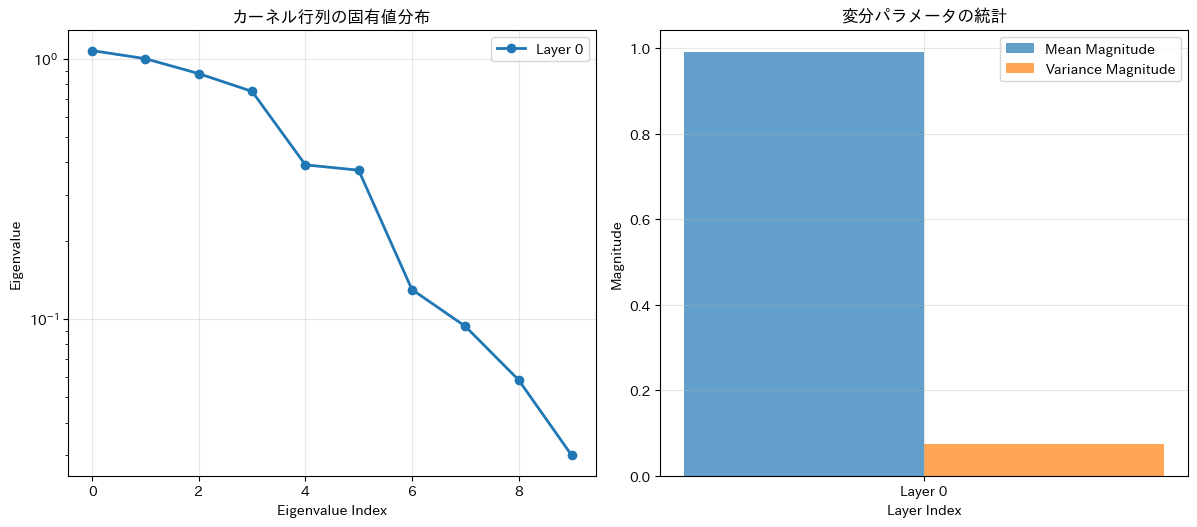

=== 各層の詳細分析 ===

--- Layer 0 ---
  カーネル行列の条件数: 3.61e+01
  最小固有値: 2.99e-02
  最大固有値: 1.08e+00
  長さスケール: [0.20681629]
  信号分散: 0.4787
  ノイズ分散: 0.0038
  誘導点範囲: [-1.0740, 0.9377]
  変分平均の範囲: [-1.1319, 1.2276]

=== 拡張範囲での各層の出力統計 ===
第1層出力次元数: 1
第1層各次元の平均値: [-0.00384244]
第1層各次元の標準偏差: [0.80462027]

=== 拡張範囲での不確実性分析 ===
元の範囲での平均不確実性: 0.2059
拡張範囲での平均不確実性: 0.5025
不確実性の増加率: 2.44倍


In [ ]:
# 各層の不確実性の詳細分析
plt.figure(figsize=(18, 15))

# カーネル行列の固有値分布
plt.subplot(3, 3, 1)
for layer_idx, layer in enumerate(model.layers):
    K_uu = layer.kernel(layer.inducing_points, layer.inducing_points)
    eigenvals = torch.linalg.eigvals(K_uu).real.detach().numpy()
    eigenvals = np.sort(eigenvals)[::-1]  # 降順ソート
    plt.plot(eigenvals, "o-", label=f"Layer {layer_idx}", linewidth=2)

plt.xlabel("Eigenvalue Index")
plt.ylabel("Eigenvalue")
plt.title("カーネル行列の固有値分布")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale("log")

# 変分パラメータの統計
plt.subplot(3, 3, 2)
layer_means = []
layer_vars = []
for layer_idx, layer in enumerate(model.layers):
    var_mean = layer.variational_mean.detach().numpy()

    var_log_cov = layer.log_variational_variance.detach().numpy()
    var_cov = np.exp(var_log_cov)

    layer_means.append(np.mean(np.abs(var_mean)))
    layer_vars.append(np.mean(np.diagonal(var_cov, axis1=0, axis2=1)))

x_pos = np.arange(len(layer_means))
plt.bar(x_pos - 0.2, layer_means, 0.4, label="Mean Magnitude", alpha=0.7)
plt.bar(x_pos + 0.2, layer_vars, 0.4, label="Variance Magnitude", alpha=0.7)
plt.xlabel("Layer Index")
plt.ylabel("Magnitude")
plt.title("変分パラメータの統計")
plt.xticks(x_pos, [f"Layer {i}" for i in range(len(layer_means))])
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

# 数値的な分析結果の出力
print("=== 各層の詳細分析 ===")
for layer_idx, layer in enumerate(model.layers):
    print(f"\n--- Layer {layer_idx} ---")

    # カーネル行列の条件数
    K_uu = layer.kernel(layer.inducing_points, layer.inducing_points)
    eigenvals = torch.linalg.eigvals(K_uu).real
    min_eigenval = torch.min(eigenvals).item()
    max_eigenval = torch.max(eigenvals).item()
    cond_num = max_eigenval / max(min_eigenval, 1e-12)

    print(f"  カーネル行列の条件数: {cond_num:.2e}")
    print(f"  最小固有値: {min_eigenval:.2e}")
    print(f"  最大固有値: {max_eigenval:.2e}")

    # ハイパーパラメータ
    print(f"  長さスケール: {layer.lengthscale.detach().numpy()}")
    print(f"  信号分散: {layer.variance.detach().numpy():.4f}")
    print(f"  ノイズ分散: {layer.noise.detach().numpy():.4f}")

    # 誘導点の範囲
    z_range = layer.inducing_points.detach()
    print(f"  誘導点範囲: [{z_range.min().item():.4f}, {z_range.max().item():.4f}]")

    # 変分パラメータの統計
    var_mean = layer.variational_mean.detach()
    print(
        f"  変分平均の範囲: [{var_mean.min().item():.4f}, {var_mean.max().item():.4f}]"
    )

print(f"\n=== 拡張範囲での各層の出力統計 ===")
print(f"第1層出力次元数: {num_dims_layer0}")
print(f"第1層各次元の平均値: {np.mean(layer_0_mean_ext_np, axis=0)}")
print(f"第1層各次元の標準偏差: {np.std(layer_0_mean_ext_np, axis=0)}")
if num_dims_layer0 > 1:
    print(
        f"第1層次元間の最大相関: {np.max(np.abs(np.corrcoef(layer_0_mean_ext_np.T) - np.eye(num_dims_layer0))):.4f}"
    )

# print(f"\n第2層出力次元数: {num_dims_layer1}")
# print(f"第2層各次元の平均値: {np.mean(layer_1_mean_ext_np, axis=0)}")
# print(f"第2層各次元の標準偏差: {np.std(layer_1_mean_ext_np, axis=0)}")
# if num_dims_layer1 > 1:
#     print(
#         f"第2層次元間の最大相関: {np.max(np.abs(np.corrcoef(layer_1_mean_ext_np.T) - np.eye(num_dims_layer1))):.4f}"
#     )

# 拡張範囲での不確実性の分析
print(f"\n=== 拡張範囲での不確実性分析 ===")
orig_indices = (x_extended_np >= orig_min) & (x_extended_np <= orig_max)
extended_indices = ~orig_indices

final_uncertainty_orig = np.mean(final_std_ext_np[orig_indices])
final_uncertainty_ext = np.mean(final_std_ext_np[extended_indices])

print(f"元の範囲での平均不確実性: {final_uncertainty_orig:.4f}")
print(f"拡張範囲での平均不確実性: {final_uncertainty_ext:.4f}")
print(f"不確実性の増加率: {final_uncertainty_ext/final_uncertainty_orig:.2f}倍")